# TrOCR READ – Baseline Fine-Tuning on READ Dataset

Fine-tuning of `microsoft/trocr-base-handwritten` **directly** on the READ Dataset (ICFHR 2016),  
without any prior Bentham fine-tuning.  

**Purpose:** Comparison baseline against `inkference_READ_ar.ipynb`  
(which starts from the Bentham checkpoint).  

| | This notebook | inkference_READ_ar |
|---|---|---|
| Starting checkpoint | `trocr-base-handwritten` | `checkpoints/best/` (Bentham) |
| Learning rate | 1e-5 | 5e-6 |
| Saved to | `checkpoints/best_read_base/` | `checkpoints/best_read/` |

## Step 1 – Understand the Dataset

In [1]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

from pathlib import Path
import xml.etree.ElementTree as ET
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches

ROOT     = Path("..")
READ_DIR = ROOT / "data" / "READDataset"

SPLITS = {
    "train": {
        "images": READ_DIR / "Training" / "Images",
        "xmls":   READ_DIR / "Training" / "page" / "page",
    },
    "val": {
        "images": READ_DIR / "Validation" / "Images",
        "xmls":   READ_DIR / "Validation" / "page" / "page",
    },
    "test": {
        "images": READ_DIR / "Test-ICFHR-2016",
        "xmls":   READ_DIR / "Test-ICFHR-2016" / "page",
    },
}

PAGE_NS = "http://schema.primaresearch.org/PAGE/gts/pagecontent/2013-07-15"

print("Paths present:")
for split, paths in SPLITS.items():
    for key, p in paths.items():
        print(f"  {'✓' if p.exists() else '✗'} [{split}/{key}] {p}")

Paths present:
  ✓ [train/images] ../data/READDataset/Training/Images
  ✓ [train/xmls] ../data/READDataset/Training/page/page
  ✓ [val/images] ../data/READDataset/Validation/Images
  ✓ [val/xmls] ../data/READDataset/Validation/page/page
  ✓ [test/images] ../data/READDataset/Test-ICFHR-2016
  ✓ [test/xmls] ../data/READDataset/Test-ICFHR-2016/page


In [2]:
ns = {"p": PAGE_NS}

for split, paths in SPLITS.items():
    n_images = len(list(paths["images"].glob("*.JPG")))
    n_xmls   = len(list(paths["xmls"].glob("*.xml")))
    total_lines = 0
    for xml_file in paths["xmls"].glob("*.xml"):
        tree = ET.parse(xml_file)
        for line in tree.getroot().findall(".//p:TextLine", ns):
            u = line.find(".//p:Unicode", ns)
            if u is not None and (u.text or "").strip():
                total_lines += 1
    print(f"{split:6s} | {n_images:>4} pages | {n_xmls:>4} XMLs | {total_lines:>5} usable lines")

train  |  350 pages |  350 XMLs |  8366 usable lines
val    |   50 pages |   50 XMLs |  1040 usable lines
test   |   50 pages |   50 XMLs |  1138 usable lines


## Step 2 – Extract Line Crops & Build DataFrame

Only lines from `paragraph` and `heading` regions are kept.  
Regions with no `type` attribute (test set) are included.

In [3]:
import pandas as pd

KEEP_REGION_TYPES = {"paragraph", "heading"}

def parse_page_xml(xml_path: Path, image_path: Path) -> list:
    ns = {"p": PAGE_NS}
    records = []
    for region in ET.parse(xml_path).getroot().findall(".//p:TextRegion", ns):
        rtype = region.get("type")
        if rtype is not None and rtype not in KEEP_REGION_TYPES:
            continue
        for line in region.findall(".//p:TextLine", ns):
            u      = line.find(".//p:Unicode", ns)
            coords = line.find("p:Coords", ns)
            if u is None or not (u.text or "").strip() or coords is None:
                continue
            pts  = coords.get("points", "")
            xs   = [int(p.split(",")[0]) for p in pts.split()]
            ys   = [int(p.split(",")[1]) for p in pts.split()]
            bbox = (min(xs), min(ys), max(xs), max(ys))
            if bbox[2] > bbox[0] and bbox[3] > bbox[1]:
                records.append({"image_path": str(image_path), "bbox": bbox,
                                 "transcription": u.text.strip()})
    return records


def build_dataframe(split_name: str) -> pd.DataFrame:
    paths, records = SPLITS[split_name], []
    for xml_file in sorted(paths["xmls"].glob("*.xml")):
        img_file = paths["images"] / (xml_file.stem + ".JPG")
        if img_file.exists():
            records.extend(parse_page_xml(xml_file, img_file))
    return pd.DataFrame(records)


df_train = build_dataframe("train")
df_val   = build_dataframe("val")
df_test  = build_dataframe("test")

print(f"Train : {len(df_train):>5} lines")
print(f"Val   : {len(df_val):>5} lines")
print(f"Test  : {len(df_test):>5} lines")

Train :  7140 lines
Val   :   894 lines
Test  :  1138 lines


## Step 3 – Preprocess Images

In [4]:
import random
import numpy as np
import torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False
print(f"Random seed set to {SEED}")

Random seed set to 42


Crop size : (1212, 105)
Text      : 'mansdorf. Zū NeūPerg. Freÿ¬'


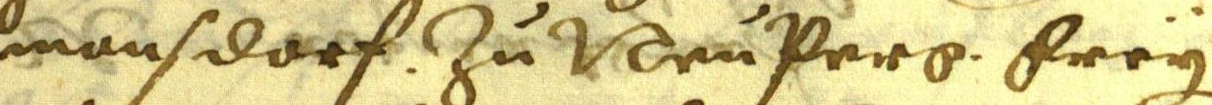

In [5]:
_page_cache: dict = {}

def load_line_image(image_path: str, bbox: tuple) -> Image.Image:
    """Crop one text line from a full-page JPG and return an RGB PIL image."""
    if image_path not in _page_cache:
        _page_cache[image_path] = Image.open(image_path).convert("RGB")
    return _page_cache[image_path].crop(bbox)


# Sanity check
row  = df_train.iloc[10]
crop = load_line_image(row["image_path"], row["bbox"])
print(f"Crop size : {crop.size}")
print(f"Text      : '{row['transcription']}'")
crop

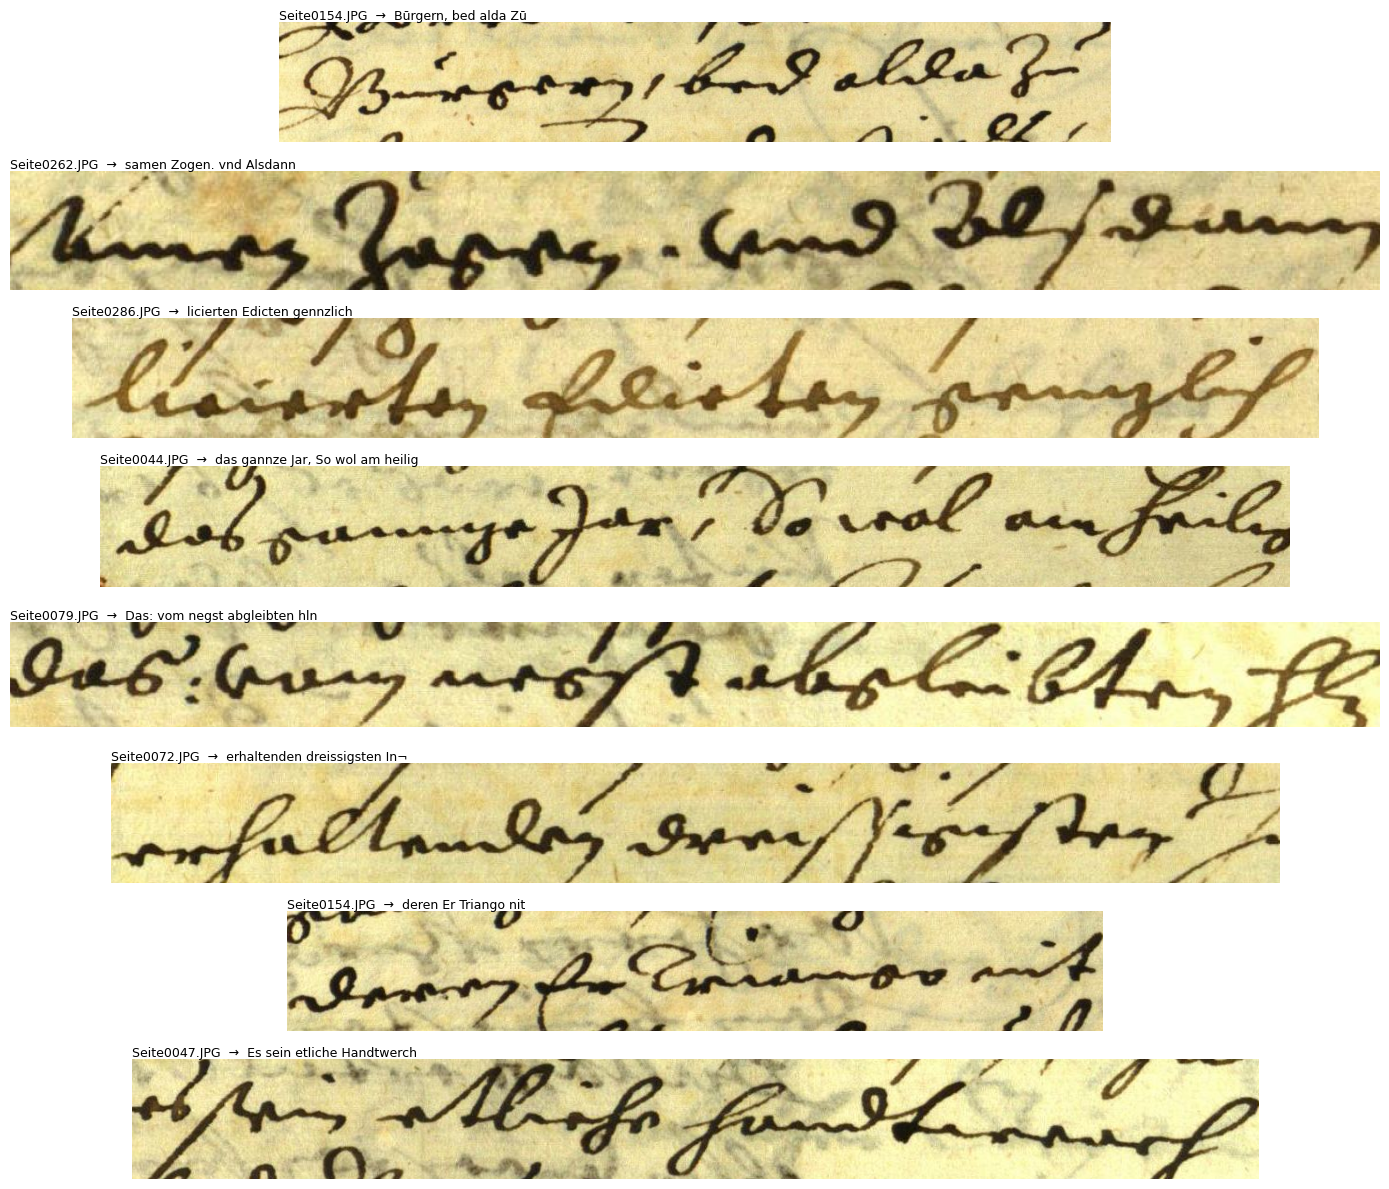

In [6]:
# Visualise 8 random training crops from different pages
sample = df_train.sample(8, random_state=SEED).reset_index(drop=True)

fig, axes = plt.subplots(8, 1, figsize=(14, 12))
for ax, (_, row) in zip(axes, sample.iterrows()):
    crop = load_line_image(row["image_path"], row["bbox"])
    ax.imshow(crop)
    ax.set_title(
        f"{Path(row['image_path']).name}  →  {row['transcription']}",
        fontsize=9, loc="left", pad=2,
    )
    ax.axis("off")
plt.tight_layout()
plt.show()

## Step 4 – Build Dataset Object

In [7]:
from transformers import TrOCRProcessor

# Load from base pre-trained model — no Bentham fine-tuning
processor = TrOCRProcessor.from_pretrained("microsoft/trocr-base-handwritten")
print("Processor loaded from: microsoft/trocr-base-handwritten")

/home/justin/Ginger_Gradient/14/project/Capstone-Project/.venv/lib/python3.11/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Processor loaded from: microsoft/trocr-base-handwritten


In [8]:
from torch.utils.data import Dataset, DataLoader

class READDataset(Dataset):
    def __init__(self, df, processor, max_target_length=128):
        self.df, self.processor = df, processor
        self.max_target_length  = max_target_length

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row          = self.df.iloc[idx]
        img          = load_line_image(row["image_path"], row["bbox"])
        pixel_values = self.processor(images=img, return_tensors="pt").pixel_values.squeeze(0)
        labels = self.processor.tokenizer(
            row["transcription"], padding="max_length",
            max_length=self.max_target_length, truncation=True, return_tensors="pt",
        ).input_ids.squeeze(0)
        labels[labels == self.processor.tokenizer.pad_token_id] = -100
        return {"pixel_values": pixel_values, "labels": labels}

In [9]:
train_dataset = READDataset(df_train, processor)
val_dataset   = READDataset(df_val,   processor)
test_dataset  = READDataset(df_test,  processor)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=16, shuffle=False, num_workers=0)

batch = next(iter(train_loader))
print(f"Batch pixel_values : {batch['pixel_values'].shape}")
print(f"Batch labels       : {batch['labels'].shape}")
print("DataLoader OK.")

Batch pixel_values : torch.Size([16, 3, 384, 384])
Batch labels       : torch.Size([16, 128])
DataLoader OK.


## Step 5 – Load & Configure TrOCR

Loaded from `microsoft/trocr-base-handwritten` — the generic pre-trained model,  
**without** any prior Bentham fine-tuning. LR=1e-5 (same as the original Bentham training).

In [10]:
from transformers import VisionEncoderDecoderModel

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

model = VisionEncoderDecoderModel.from_pretrained("microsoft/trocr-base-handwritten")

# Decoder configuration — required when loading from base model
model.config.decoder_start_token_id = processor.tokenizer.cls_token_id
model.config.pad_token_id           = processor.tokenizer.pad_token_id
model.config.eos_token_id           = processor.tokenizer.sep_token_id

# Gradient checkpointing: saves ~60-70% VRAM at the cost of ~20% longer training time
model.config.use_cache = False
model.gradient_checkpointing_enable()

model.to(device)
print("Model loaded from : microsoft/trocr-base-handwritten")
print("Gradient checkpointing active.")

Device: cuda


/home/justin/Ginger_Gradient/14/project/Capstone-Project/.venv/lib/python3.11/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of VisionEncoderDecoderModel were not initialized from the model checkpoint at microsoft/trocr-base-handwritten and are newly initialized: ['encoder.pooler.dense.bias', 'encoder.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model loaded from : microsoft/trocr-base-handwritten
Gradient checkpointing active.


In [11]:
from torch.optim import AdamW
from transformers import get_scheduler

EPOCHS        = 30
LEARNING_RATE = 1e-5   # same as Bentham training — starting from generic pre-trained model
WARMUP_RATIO  = 0.1

total_steps  = EPOCHS * len(train_loader)
warmup_steps = int(total_steps * WARMUP_RATIO)

optimizer = AdamW(model.parameters(), lr=LEARNING_RATE)
scheduler = get_scheduler(
    name="linear", optimizer=optimizer,
    num_warmup_steps=warmup_steps, num_training_steps=total_steps,
)

print(f"Total training steps : {total_steps}")
print(f"Warmup steps         : {warmup_steps}")
print(f"Optimizer            : AdamW, LR={LEARNING_RATE}")
print(f"Scheduler            : Linear Warmup → Linear Decay")

Total training steps : 13410
Warmup steps         : 1341
Optimizer            : AdamW, LR=1e-05
Scheduler            : Linear Warmup → Linear Decay


## Step 6 – Training Loop

Per epoch: train → measure validation CER → save checkpoint → check early stopping.  
Patience = 3 epochs without improvement in validation CER.  
Best checkpoint saved to `../checkpoints/best_read_base/`.

In [12]:
import evaluate

cer_metric = evaluate.load("cer")

def compute_cer(model, dataloader, processor, device):
    """Compute CER on a dataloader split."""
    model.eval()
    all_preds, all_refs = [], []
    with torch.no_grad():
        for batch in dataloader:
            pixel_values = batch["pixel_values"].to(device)
            labels       = batch["labels"].clone()
            generated_ids = model.generate(pixel_values, max_new_tokens=128)
            preds = processor.batch_decode(generated_ids, skip_special_tokens=True)
            labels[labels == -100] = processor.tokenizer.pad_token_id
            refs = processor.batch_decode(labels, skip_special_tokens=True)
            all_preds.extend(preds)
            all_refs.extend(refs)
    return cer_metric.compute(predictions=all_preds, references=all_refs)

In [13]:
from tqdm.notebook import tqdm

PATIENCE              = 3
BASE_CHECKPOINT_DIR   = Path("../checkpoints/best_read_base")
BASE_CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

best_cer         = float("inf")
patience_counter = 0
history          = []
scaler           = torch.amp.GradScaler("cuda")

if torch.cuda.is_available():
    torch.cuda.empty_cache()

for epoch in range(1, EPOCHS + 1):

    # ── Training ────────────────────────────────────────────────────────────
    model.train()
    total_loss = 0.0

    for batch in tqdm(train_loader, desc=f"Epoch {epoch:02d}/{EPOCHS} [train]", leave=False):
        pixel_values = batch["pixel_values"].to(device)
        labels       = batch["labels"].to(device)
        optimizer.zero_grad()
        with torch.amp.autocast("cuda"):
            outputs = model(pixel_values=pixel_values, labels=labels)
        scaler.scale(outputs.loss).backward()
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()
        total_loss += outputs.loss.item()

    avg_loss = total_loss / len(train_loader)

    # ── Validation CER ──────────────────────────────────────────────────────
    val_cer = compute_cer(model, val_loader, processor, device)

    history.append({"epoch": epoch, "train_loss": avg_loss, "val_cer": val_cer})
    print(f"Epoch {epoch:02d} | Loss: {avg_loss:.4f} | Val CER: {val_cer:.4f}", end="")

    # ── Checkpoint & Early Stopping ─────────────────────────────────────────
    if val_cer < best_cer:
        best_cer         = val_cer
        patience_counter = 0
        model.save_pretrained(BASE_CHECKPOINT_DIR)
        processor.save_pretrained(BASE_CHECKPOINT_DIR)
        print(f"  ✓ Best model saved")
    else:
        patience_counter += 1
        print(f"  ✗ No improvement ({patience_counter}/{PATIENCE})")
        if patience_counter >= PATIENCE:
            print(f"\nEarly stopping after epoch {epoch} — best Val CER: {best_cer:.4f}")
            break

Epoch 01/30 [train]:   0%|          | 0/447 [00:00<?, ?it/s]

Epoch 01 | Loss: 5.2477 | Val CER: 0.2550  ✓ Best model saved


Epoch 02/30 [train]:   0%|          | 0/447 [00:00<?, ?it/s]

Epoch 02 | Loss: 1.0840 | Val CER: 0.1350  ✓ Best model saved


Epoch 03/30 [train]:   0%|          | 0/447 [00:00<?, ?it/s]

...

Epoch 26 | Loss: 0.0041 | Val CER: 0.0586  ✗ No improvement (1/3)


Epoch 27/30 [train]:   0%|          | 0/447 [00:00<?, ?it/s]

Epoch 27 | Loss: 0.0031 | Val CER: 0.0599  ✗ No improvement (2/3)


Epoch 28/30 [train]:   0%|          | 0/447 [00:00<?, ?it/s]

Epoch 28 | Loss: 0.0030 | Val CER: 0.0586  ✗ No improvement (3/3)

Early stopping after epoch 28 — best Val CER: 0.0580


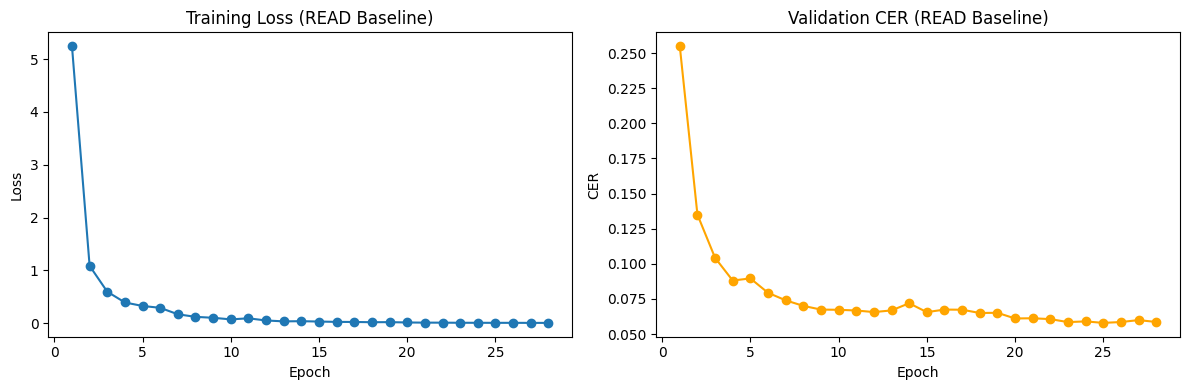


Best Validation CER: 0.0580 (Epoch 25)


In [14]:
history_df = pd.DataFrame(history)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history_df["epoch"], history_df["train_loss"], marker="o")
ax1.set_title("Training Loss (READ Baseline)")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax2.plot(history_df["epoch"], history_df["val_cer"], marker="o", color="orange")
ax2.set_title("Validation CER (READ Baseline)")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("CER")
plt.tight_layout()
plt.show()
print(f"\nBest Validation CER: {history_df['val_cer'].min():.4f} (Epoch {history_df['val_cer'].idxmin() + 1})")

## Step 7 – Evaluation

Load best checkpoint → CER & WER on the test set → qualitative comparison.  
Self-contained: can be run after a kernel restart without retraining.

In [19]:
import torch
import evaluate
import xml.etree.ElementTree as ET
import pandas as pd
from pathlib import Path
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from tqdm.notebook import tqdm
from transformers import VisionEncoderDecoderModel, TrOCRProcessor

READ_DIR              = Path("../data/READDataset")
BASE_CHECKPOINT_DIR   = Path("../checkpoints/best_read_base")
PAGE_NS               = "http://schema.primaresearch.org/PAGE/gts/pagecontent/2013-07-15"
KEEP_REGION_TYPES     = {"paragraph", "heading"}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Rebuild test DataFrame
def _parse_xml(xml_path, image_path):
    ns, records = {"p": PAGE_NS}, []
    for region in ET.parse(xml_path).getroot().findall(".//p:TextRegion", ns):
        rtype = region.get("type")
        if rtype is not None and rtype not in KEEP_REGION_TYPES:
            continue
        for line in region.findall(".//p:TextLine", ns):
            u      = line.find(".//p:Unicode", ns)
            coords = line.find("p:Coords", ns)
            if u is None or not (u.text or "").strip() or coords is None:
                continue
            pts  = coords.get("points", "")
            xs   = [int(p.split(",")[0]) for p in pts.split()]
            ys   = [int(p.split(",")[1]) for p in pts.split()]
            bbox = (min(xs), min(ys), max(xs), max(ys))
            if bbox[2] > bbox[0] and bbox[3] > bbox[1]:
                records.append({"image_path": str(image_path), "bbox": bbox,
                                 "transcription": u.text.strip()})
    return records

test_xml_dir = READ_DIR / "Test-ICFHR-2016" / "page"
test_img_dir = READ_DIR / "Test-ICFHR-2016"
records = []
for xml_file in sorted(test_xml_dir.glob("*.xml")):
    img_file = test_img_dir / (xml_file.stem + ".JPG")
    if img_file.exists():
        records.extend(_parse_xml(xml_file, img_file))
df_test_eval = pd.DataFrame(records)

best_model     = VisionEncoderDecoderModel.from_pretrained(BASE_CHECKPOINT_DIR).to(device)
best_processor = TrOCRProcessor.from_pretrained(BASE_CHECKPOINT_DIR)
best_model.eval()

print(f"Device     : {device}")
print(f"Checkpoint : {BASE_CHECKPOINT_DIR}")
print(f"Test lines : {len(df_test_eval)}")

Device     : cuda
Checkpoint : ../checkpoints/best_read_base
Test lines : 1138


In [20]:
class _READDataset(Dataset):
    def __init__(self, df, processor, max_target_length=128):
        self.df, self.processor = df, processor
        self.max_target_length  = max_target_length
        self._cache = {}

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        if row["image_path"] not in self._cache:
            self._cache[row["image_path"]] = Image.open(row["image_path"]).convert("RGB")
        img          = self._cache[row["image_path"]].crop(row["bbox"])
        pixel_values = self.processor(images=img, return_tensors="pt").pixel_values.squeeze(0)
        labels = self.processor.tokenizer(
            row["transcription"], padding="max_length",
            max_length=self.max_target_length, truncation=True, return_tensors="pt",
        ).input_ids.squeeze(0)
        labels[labels == self.processor.tokenizer.pad_token_id] = -100
        return {"pixel_values": pixel_values, "labels": labels}


cer_metric = evaluate.load("cer")
wer_metric = evaluate.load("wer")

test_loader = DataLoader(
    _READDataset(df_test_eval, best_processor),
    batch_size=16, shuffle=False, num_workers=0,
)

all_preds, all_refs = [], []
with torch.no_grad():
    for batch in tqdm(test_loader, desc="Evaluating"):
        pixel_values = batch["pixel_values"].to(device)
        labels       = batch["labels"].clone()
        generated_ids = best_model.generate(pixel_values, max_new_tokens=128)
        preds = best_processor.batch_decode(generated_ids, skip_special_tokens=True)
        labels[labels == -100] = best_processor.tokenizer.pad_token_id
        refs  = best_processor.batch_decode(labels, skip_special_tokens=True)
        all_preds.extend(preds)
        all_refs.extend(refs)

cer = cer_metric.compute(predictions=all_preds, references=all_refs)
wer = wer_metric.compute(predictions=all_preds, references=all_refs)

print(f"\nTest CER : {cer:.4f}  ({cer*100:.2f}%)")
print(f"Test WER : {wer:.4f}  ({wer*100:.2f}%)")

Evaluating:   0%|          | 0/72 [00:00<?, ?it/s]


Test CER : 0.0618  (6.18%)
Test WER : 0.2724  (27.24%)


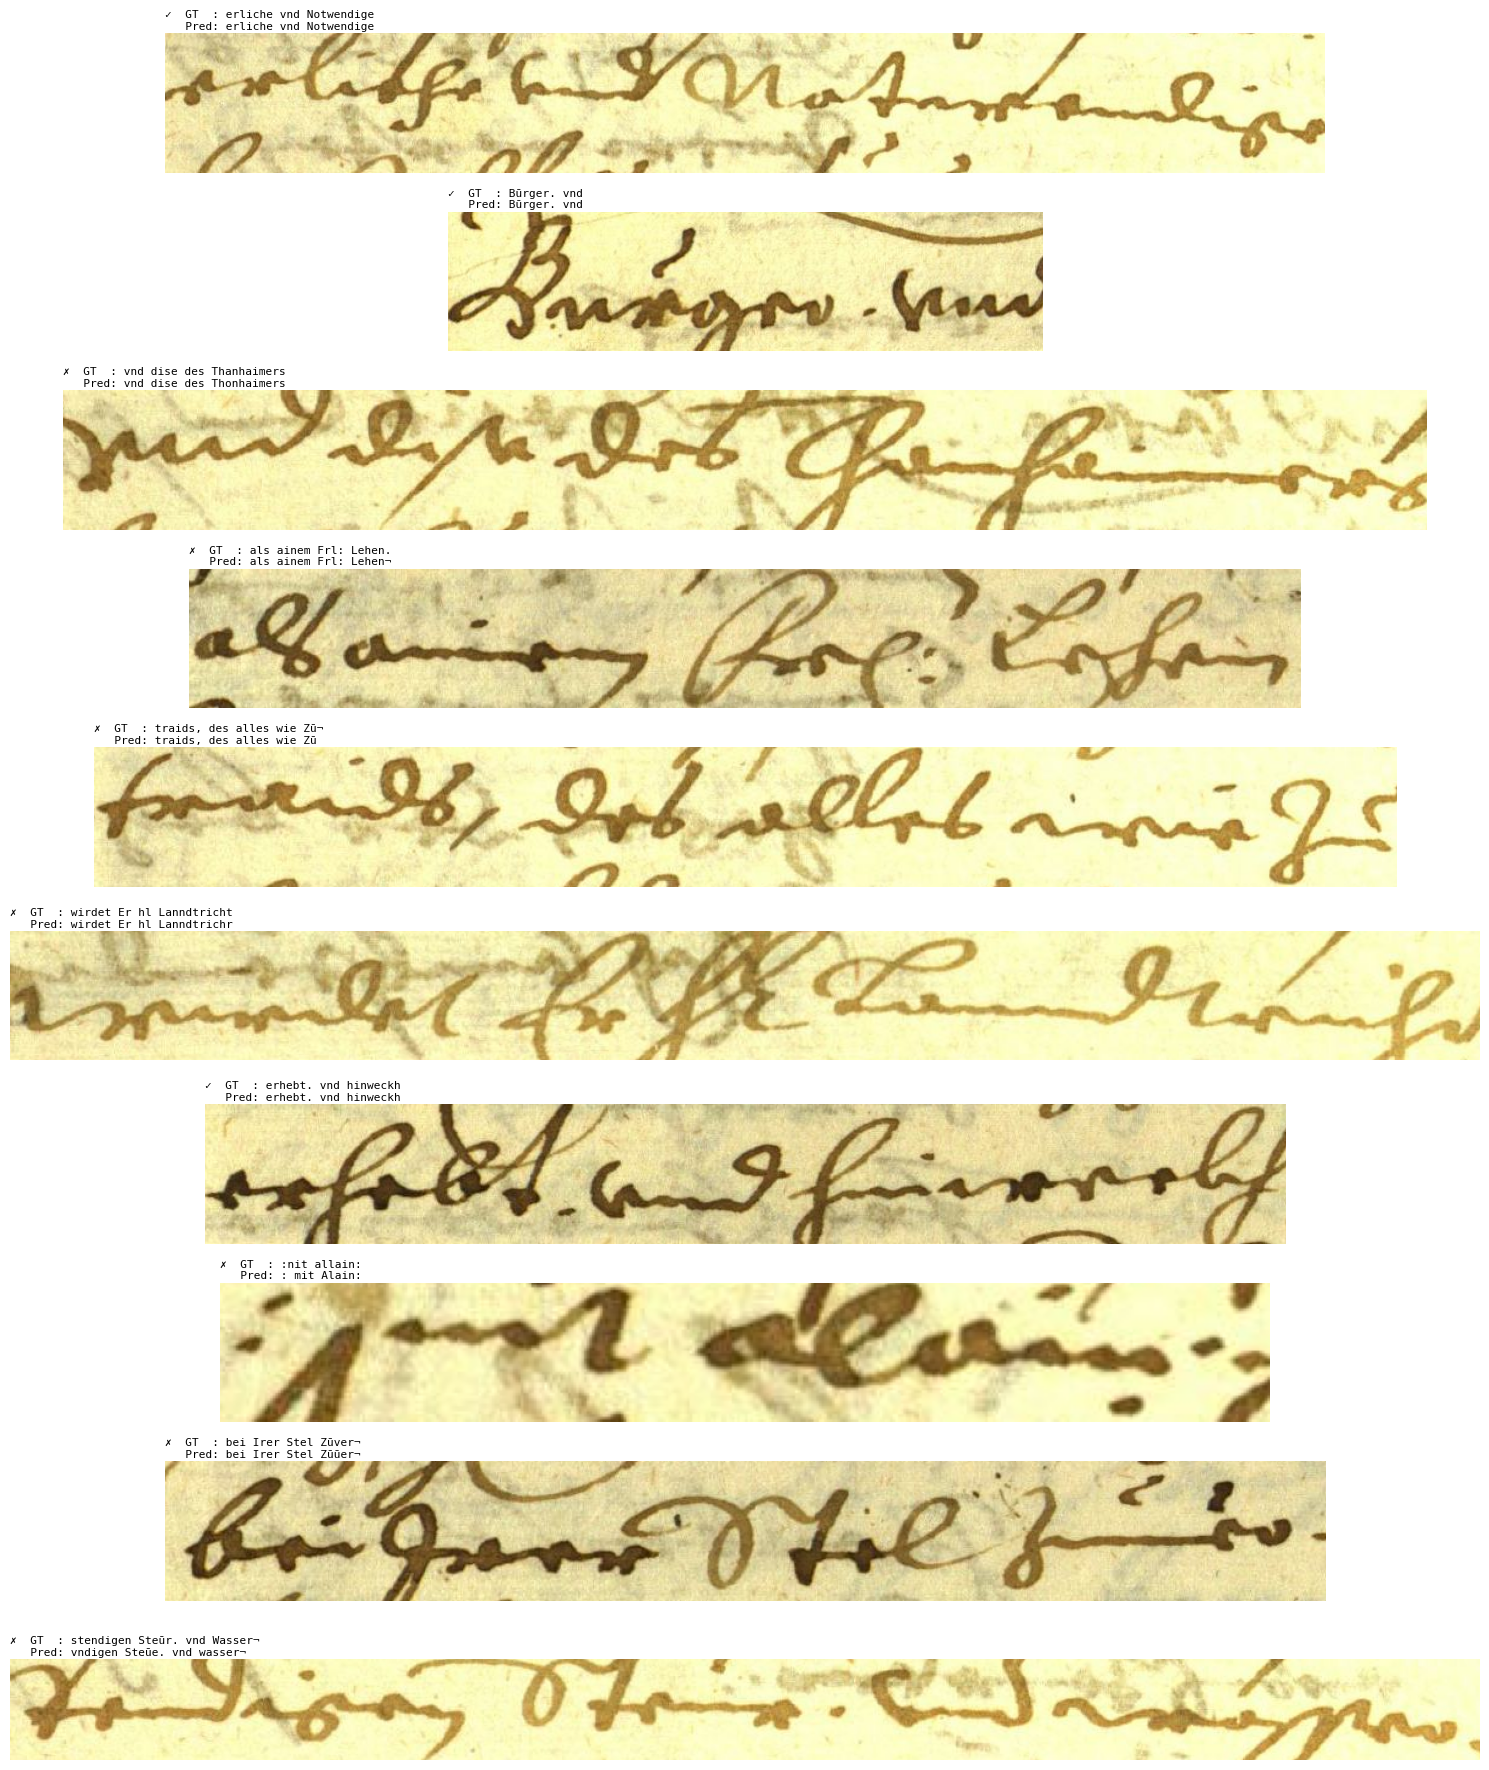

In [21]:
import matplotlib.pyplot as plt

sample_idx = df_test_eval.sample(10, random_state=42).index.tolist()

fig, axes = plt.subplots(10, 1, figsize=(15, 18))
for ax, idx in zip(axes, sample_idx):
    row   = df_test_eval.iloc[idx]
    img   = Image.open(row["image_path"]).crop(row["bbox"])
    pred  = all_preds[idx]
    ref   = all_refs[idx]
    match = "✓" if pred.strip() == ref.strip() else "✗"
    ax.imshow(img)
    ax.set_title(
        f"{match}  GT  : {ref}\n   Pred: {pred}",
        fontsize=8, loc="left", pad=3, family="monospace",
    )
    ax.axis("off")
plt.tight_layout()
plt.show()

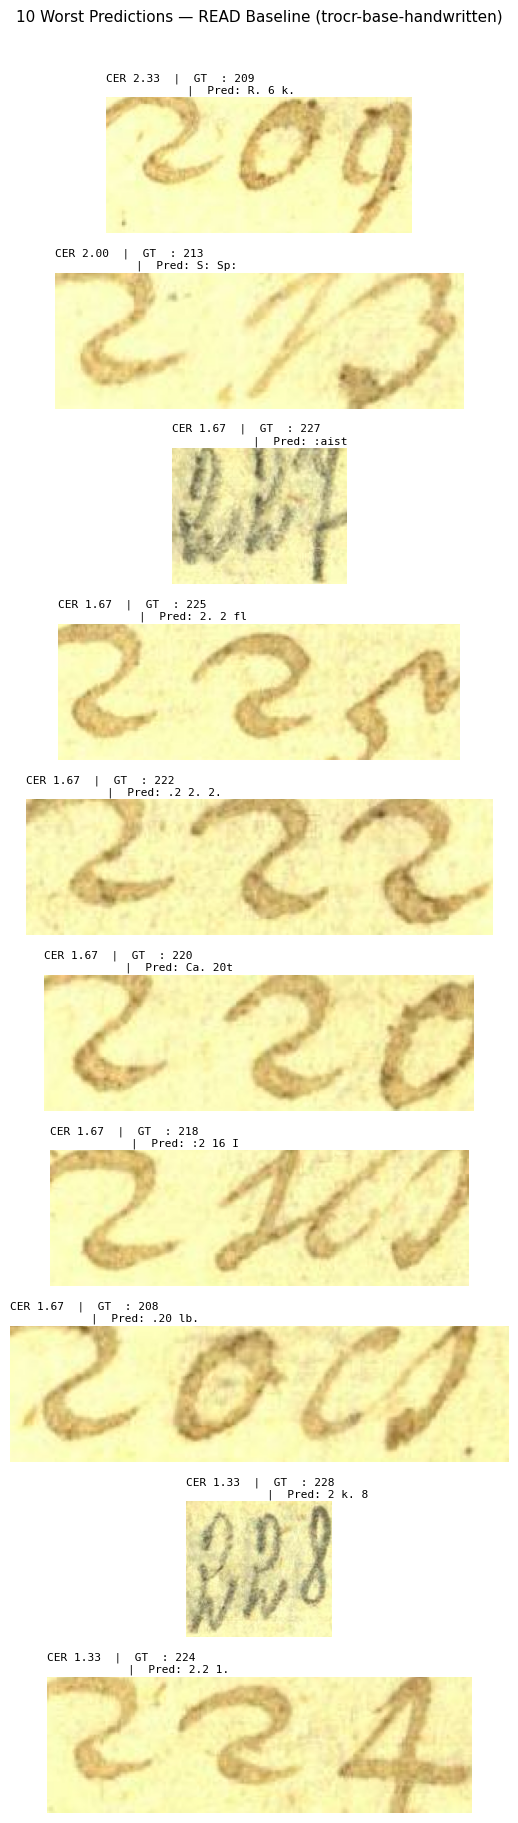

Saved to ../checkpoints/best_read_base/worst_predictions.png


In [22]:
# 10 worst predictions with visual crop
from jiwer import cer as line_cer

errors = sorted(
    [(line_cer(ref, pred), idx, ref, pred)
     for idx, (pred, ref) in enumerate(zip(all_preds, all_refs)) if ref.strip()],
    reverse=True,
)
worst = errors[:10]

fig, axes = plt.subplots(10, 1, figsize=(15, 18))
for ax, (c, idx, ref, pred) in zip(axes, worst):
    row = df_test_eval.iloc[idx]
    img = Image.open(row["image_path"]).crop(row["bbox"])
    ax.imshow(img)
    ax.set_title(
        f"CER {c:.2f}  |  GT  : {ref}\n"
        f"            |  Pred: {pred}",
        fontsize=8, loc="left", pad=3, family="monospace",
    )
    ax.axis("off")

plt.suptitle("10 Worst Predictions — READ Baseline (trocr-base-handwritten)", fontsize=11, y=1.01)
plt.tight_layout()

output_path = Path("../checkpoints/best_read_base/worst_predictions.png")
plt.savefig(output_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved to {output_path}")